# Setup

In [1]:
from cause_identification import Metrics, CausalObservation, Granularity
from flocking import Scenarii
from utils import get_3_axes
from experiments import load_scms

pygame 2.6.1 (SDL 2.28.4, Python 3.12.9)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [2]:
import numpy as np, matplotlib.pyplot as plt

# Utils

In [3]:
def show_cause(cause, variables, instance, score=None, label="Cause: ", 
               show=True, force_line_break=True, pred_sep="\n"):
    # Label
    s = f"{label}"
    # Line break for long causes
    if (len(cause[3])>1 or force_line_break) and label:
        s += "\n"
    # Repr cause
    s += pred_sep.join([f'{variables[dim]}={instance[dim]:.2f}' for dim in cause[3]])
    # Line break for long causes
    if score is not None:
        if force_line_break:
            s += '\n'
        if isinstance(score, float):
            s += f" -> {score=:.2f}"
        else:
            s += f" -> {score=}"
    if show:
        print(s) 
    else:
        return s

In [4]:
def filter_causes_percentile(scores, k):
    id_sets = []
    for i in range(3):
        valid_ids = get_percentile(scores[i], k)
        id_sets.append(set(valid_ids))
    return np.array(list(set.intersection(*id_sets)))

In [5]:
def get_percentile(score, k):
    threshold = np.percentile(score, k)
    return np.argwhere(score <= threshold).flatten()

In [6]:
def render_cause(cause, variables, instance, flock_mapping, actual_run, hp):
    _, axes = plt.subplots(1,len(cause[0]), squeeze=False)
    axes = axes[0]
    for ax, (dim, cf_value) in zip(axes, cause[0]):
        causal_var = variables[dim]
        actual_value = instance[dim]
        cf_info = f", cf={cf_value:.2f}" if actual_value != cf_value else ""
        ent_type, ent_id, obs_var_label, t = break_var(causal_var)
        causal_label = f"{ent_type}={ent_id}, t={t}\n{obs_var_label}={actual_value:.2f}"
        title = causal_label + cf_info
        # ax.set_title(title)
        boid_ids = get_boid_ids_once(causal_var, flock_mapping)
        show_boids(actual_run[t], hp, highlight_ids=boid_ids, ax=ax, title=title)
    plt.tight_layout()
    plt.show()

In [7]:
def plot_score_distibution(scores, metrics, round_x=True, hist_cost=True):
    axes = get_3_axes(sharey=True)
    axes[0].set_yscale('log')
    if hist_cost:
        axes[0].hist(scores[0], bins=100)
        ids = (1,2)
    else:
        ids = (0,1,2)
    
    for i in ids:
        counter = Counter(scores[i])
        X, Y = zip(*counter.items())
        ids = np.argsort(X)
        if round_x:
            axes[i].bar([str(round(X[i])) for i in ids], [Y[i] for i in ids])
        else:
            axes[i].bar([str(round(X[i],2)) for i in ids], [Y[i] for i in ids])
            axes[i].tick_params('x', rotation=45)
    for i in range(3):
        axes[i].set_title(metrics[i])
    plt.suptitle("Metric distribution over the 5 SCMs")
    plt.tight_layout()
    plt.show()

In [8]:
def plot_score_distibution(scores, metrics, cost_bin_counts, cost_bin_edges):
    axes = get_3_axes(sharey=True)
    axes[0].set_yscale('log')
    plot_cost(cost_bin_edges, cost_bin_counts, axes[0])
    axes[0].tick_params('x', rotation=45)
    
    for i in (1,2):
        counter = Counter(scores[i])
        X, Y = zip(*counter.items())
        ids = np.argsort(X)
        axes[i].bar([str(round(X[i])) for i in ids], [Y[i] for i in ids])
            
    for i in range(3):
        axes[i].set_title(metrics[i])
    plt.suptitle("Metric distribution over the 5 SCMs")
    plt.tight_layout()
    plt.show()

In [9]:
def plot_cost(bin_edges, bin_counts, ax):
    ax.bar([f'{elt:.0%}' for elt in bin_edges], bin_counts)

In [10]:
def plot_score_2D(scores, metrics):
    _, axes = plt.subplots(2,2)
    for i in range(3):
        for j in range(i+1, 3):
            axes[j-1,i-1].scatter(scores[i], scores[j], alpha=.1)
            axes[j-1,i-1].set_xlabel(metrics[i])
            axes[j-1,i-1].set_ylabel(metrics[j])
    axes[0,0].set_axis_off()
    plt.suptitle("Metric distribution 2D")
    plt.tight_layout()
    plt.show()

In [11]:
def get_causes_scenario(scenario):
    scms = load_scms(scenario, prefix="../")
    causes, scores, scm_refs = get_causes(scms)
    return causes, scores, scm_refs, scms

In [12]:
def get_causes(scms):
    causes = []
    metrics = [m.value for m in Metrics]
    scores = []
    scm_refs = []
    for i, scm in enumerate(scms):
        if "causes" not in scm.__dict__:
            continue
        causes += scm.causes
        scm.compute_scores()
        scores.append([scm.scores[metric] for metric in metrics])
        scm_refs += [i] * len(scm.causes)
        # print(scm.__class__.__name__, len(scm.causes))
    scores = np.hstack(scores)
    return causes, scores, scm_refs

In [13]:
def show_filtered_causes(causes, scores, scm_refs, scms, ids):
    # print(f"Number of cause considered {len(ids)} ({len(ids)/len(causes):.2e})")
    for i in ids:
        score = scores[:,i]
        scm = scms[scm_refs[i]]
        cause = causes[i]
        for m, s in zip(metrics, score):
            if m == Metrics.COST.value:
                print(f"{m}={s:.0%}", end=" ")
            else:
                print(f"{m}={s:.0f}", end=" ")
        print()
        render_cause(cause, scm.variables, scm.instance, scm.flock_mapping, scm.actual_run, scm.hp)

In [14]:
def filter_duplicate_causes(causes):
    return re

In [15]:
def filter_causes(scores, N):
    for i in range(100):
        ids = filter_causes_percentile(scores, i)
        if len(ids) > N:
            print(f"Data select from top {i}%")
            break
    ids = sorted(ids, key=lambda i: np.prod(scores[:,i]))[:N]
    return ids

In [16]:
def get_rouded_values(data, bins=20):
    bins = np.logspace(np.log10(data.min()), np.log10(data.max()), num=bins + 1)
    bin_indices = np.digitize(data, bins)
    bin_means = np.array([data[bin_indices == i+1].max() if i+1 in np.unique(bin_indices) else 0 for i in range(bin_indices.max())])
    return bin_means[bin_indices - 1]

In [17]:
def digitalize_cost(scores, n_bins=10):
    s = scores.copy()
    bins = np.logspace(np.log10(s[0].min()), np.log10(s[0].max()), num=n_bins + 1)
    bin_indices = np.digitize(s[0], bins)
    values = range(bin_indices.max())
    bin_edges = np.array([
        s[0][bin_indices == i+1].max() 
        if i+1 in np.unique(bin_indices) 
        else bins[i+1]
        for i in values
        ])
    bin_counts = np.array([
        s[0][bin_indices == i+1].size
        for i in values
    ])
    # print(bin_edges.shape, bin_count.shape)
    s[0] = bin_edges[bin_indices - 1]
    return s, bin_edges, bin_counts

In [18]:
def sort_causes_priority(scores, priorities):
    scores = scores.copy()
    # scores[0] = get_rouded_values(scores[0], bins=50)
    # order = [priorities[m] for m in Metrics]
    key = lambda i: (
        scores[priorities[0],i], 
        scores[priorities[1],i], 
        scores[priorities[2],i], 
    )
    # return sorted(range(scores.shape[1]), key=lambda i: (scores[0,i],test_scores[1,i], test_scores[2,i]))
    return sorted(range(scores.shape[1]), key=key)

In [19]:
def sort_causes_weights(scores, weights):
    w = np.array([weights[m] for m in Metrics]).reshape(-1,1)
    scores = np.sum(scores / scores.max(axis=1, keepdims=True) * w, axis=0)
    return np.argsort(scores)

In [20]:
def show_priority(causes, scores, s, scms, scm_refs, priority, n=5):
    ids = sort_causes_priority(s, priority)[:n]
    for i in ids:
        cause = causes[i]
        scm = scms[scm_refs[i]]
        show_cause(cause, scm.variables, scm.instance, 
                   score=scores[priority,i].round(2).tolist(),
                   pred_sep=" & ", force_line_break=False, label="")

In [21]:
def show_results(scenario, show_sim=False, show_distr=False, 
                 show_distr_2D=False, show_priorities=[],
                n=5, show_priorities_graphic=False):
    scms = load_scms(scenario)
    causes, scores, scm_refs = get_causes(scms)
    s, bin_edges, bin_counts = digitalize_cost(scores)
    if show_sim: show_simulation(scms[0].actual_run, scms[0].hp)
    if show_distr: plot_score_distibution(s, metrics, bin_counts, bin_edges)
    if show_distr_2D: plot_score_2D(s, metrics)
    for priority in show_priorities:
        print(f"Priotities: {' '.join([list(Metrics)[i].value for i in priority])}")
        show_priority(causes, scores, s, scms, scm_refs, priority, n)
        if show_priorities_graphic:
            ids = sort_causes_priority(s, priority)[:n]
            show_filtered_causes(causes, scores, scm_refs, scms, ids)
        print()

# Main

In [22]:
metrics = [m.value for m in Metrics]

## Data gathering

In [23]:
def get_states(scenario, prefix):
    scms = load_scms(scenario)
    run = scms[0].actual_run
    hp = scms[0].hp
    first_hit = get_first_hit(run, hp)
    axes = get_3_axes()
    show_boids(run[0], hp, ax=axes[0], title="Initial state")
    show_boids(run[first_hit], hp, ax=axes[1], title="Time of collision")
    show_boids(run[-1], hp, ax=axes[2], title="Final state")
    plt.tight_layout()
    plt.savefig(prefix+f"results_multi_scale/states_{scenario.value}.pdf")

In [24]:
v2l = {
    CausalObservation.BOOLEAN: "Bool.", 
    CausalObservation.PARAMS: "Param.", 
    CausalObservation.VARS: "Var."
}
a2l = {
    Granularity.BOID: "Agent",
    Granularity.FLOCK: "Flock"
}

def scm_label(scm):
    return "-".join([
            a2l[scm.entity_type], v2l[scm.obs_type]
        ])

In [25]:
def render_cost_distributions(prefix="../"):
    axes = get_3_axes()
    
    for ax, scenario in zip(axes, (Scenarii.ONE_FLOCK, Scenarii.FUSION, Scenarii.FREE)):
        causes, scores, scm_refs, scms = get_causes_scenario(scenario) 
        ax.set_title(scenario.value)
        ax.boxplot(
            [scm.scores[Metrics.COST.value] for scm in scms], 
            vert=True, patch_artist=True,
            boxprops=dict(facecolor="lightblue", color="black"),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            medianprops=dict(color="red")
        )
        
        ax.set_xticks(range(len(scms)), [scm_label(scm) for scm in scms])
        ax.tick_params('x', rotation=45)
    axes[0].set_ylabel("Intervention cost")
    plt.tight_layout()
    plt.savefig(prefix+"results_multi_scale/cost_distributions.pdf")
    plt.show()

In [26]:
def render_distributions(metric, prefix="../"):
    if metric == Metrics.COMPLEXITY:
        legend_title = 'Cause length'
        save_name = "length"
        values = np.arange(1,5)
    else:
        legend_title = 'Time to collision'
        save_name = 'oldness'
        values = None
    axes = get_3_axes(sharey=True)
    for ax, scenario in zip(axes, (Scenarii.ONE_FLOCK, Scenarii.FUSION, Scenarii.FREE)):
        causes, scores, scm_refs, scms = get_causes_scenario(scenario) 
        if metric == Metrics.OLDNESS:
            scm = scms[0]
            first_hit = get_first_hit(scm.actual_run, scm.hp)
            steps = scm.get_intervention_steps()
            values = first_hit - steps
        ax.set_title(scenario.value)
        bars = np.zeros((len(values),5))
        # bars = [[] for i in range(4)]
        x_ticks = []
        for i, scm in enumerate(scms):
            x_ticks.append(scm_label(scm))
            counter = Counter(scm.scores[metric.value])
            for j, value in enumerate(values):
                n = counter[value]
                bars[j, i] = n
        bar_width = 0.8 / len(values)
        index = np.arange(len(x_ticks))
        for i, bars_i in enumerate(bars):
            ax.bar(index + i*bar_width, bars_i, bar_width, label=values[i])#f'Cause size={i+1}')
        ax.set_xticks(index, x_ticks)
        ax.tick_params("x", rotation=45)
        ax.set_yscale("log")
        ax.legend(title=legend_title, ncol=2, fontsize=7, title_fontsize=9)
    axes[0].set_ylabel("#causes")
    plt.tight_layout()
    plt.savefig(prefix+f"results_multi_scale/{save_name}_distribution.pdf")
    plt.show()

In [27]:
def get_n_causes():
    data = []
    columns = []
    index = []
    for ax, scenario in zip(axes, (Scenarii.ONE_FLOCK, Scenarii.FUSION, Scenarii.FREE)):
        data.append([])
        index.append(scenario.value)
        causes, scores, scm_refs, scms = get_causes_scenario(scenario)
        for scm in scms:
            data[-1].append(len(scm.causes))
            columns.append(scm.__class__.__name__)
    return pd.DataFrame(data, index=index, columns=columns[:5])

Unpickling failed [Errno 2] No such file or directory: '../results_multi_scale/one_flock.pkl'


NameError: name 'init_boids_bottom' is not defined

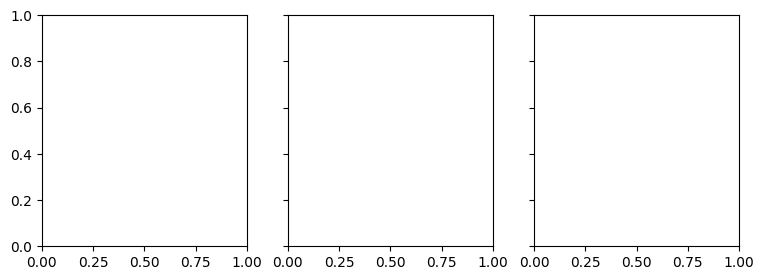

In [28]:
render_distributions(Metrics.COMPLEXITY)

In [ ]:
# render_distributions(Metrics.OLDNESS)

In [ ]:
# render_cost_distributions()

In [ ]:
# get_n_causes()

In [ ]:
# for scenario in Scenarii:
#     get_states(scenario, "../")

## Free Movement

In [ ]:
# show_results(Scenarii.FREE, show_sim=True, show_distr=True, 
#                  show_distr_2D=True)

In [ ]:
metrics

In [ ]:
priorities = [(0,1,2), (1,0,2), (2,0,1)]
show_results(Scenarii.FREE, show_priorities=priorities)

## One flock

In [ ]:
# show_results(Scenarii.ONE_FLOCK, show_sim=True, show_distr=True, 
#                  show_distr_2D=True)

In [ ]:
priorities = [(0,1,2), (1,0,2), (2,0,1)]
show_results(Scenarii.ONE_FLOCK, show_priorities=priorities)#, show_priorities_graphic=True)

## Flock Fusion

In [ ]:
# show_results(Scenarii.FUSION, show_sim=True, show_distr=True, 
#                  show_distr_2D=True)

In [ ]:
priorities = [(0,1,2), (1,0,2), (2,0,1)]
show_results(Scenarii.FUSION, show_priorities=priorities)#, show_priorities_graphic=True)

## Flock clash

In [ ]:
with open("../results_multi_scale/clash.pkl", "rb") as file:
    scms = pickle.load(file)

In [ ]:
causes, scores, scm_refs = get_causes(scms)

In [ ]:
s, bin_edges, bin_counts = digitalize_cost(scores)

In [ ]:
show_simulation(scms[0].actual_run, scms[0].hp)

In [ ]:
plot_score_distibution(s, metrics, bin_counts, bin_edges)

In [ ]:
plot_score_2D(s, metrics)

In [ ]:
n = 5
for priority in ((0,1,2), (1,0,2), (2,0,1)):
    print(f"Priotities: {' '.join([list(Metrics)[i].value for i in priority])}")
    show_priority(causes, scores, s, scms, scm_refs, priority, n)
    ids = sort_causes_priority(s, priority)[:n]
    show_filtered_causes(causes, scores, scm_refs, scms, ids)
    print()